In [1]:
from pathlib import Path
import pandas as pd
from IPython.display import Image, display
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from PIL import Image
import torch.optim as optim
from tqdm import tqdm
from vision_transformer import VisionTransformer
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import copy


MAPPING = {"FAKE": 1, "REAL": 0}
BASE = Path("/Users/mariobelotti/.cache/kagglehub/datasets/birdy654/cifake-real-and-ai-generated-synthetic-images/versions/3")

BATCH_SIZE = 256
EPOCHS = 10

# Vision Transformer params
IMG_SIZE = 32
PATCH_SIZE = 4
IN_CHANNELS = 3
CLASS_SIZE = 2 # REAL OR FAKE
N_LAYERS = 2
N_HEADS = 8
HEAD_SIZE = 256
DROPOUT_RATE = 0.1

device = torch.device("mps")

In [2]:
def build_df(base_path: Path, subset: str, shuffle: bool = True) -> pd.DataFrame:
    rows = []
    base = Path(base_path) / subset
    for label_name, label_value in MAPPING.items():
        folder = base / label_name
        if not folder.exists():
            continue
        for p in folder.rglob("*"):
            if p.is_file():
                rows.append({"path": str(p), "label": label_value})
    df = pd.DataFrame(rows)
    if df.empty:
        return df
    if shuffle:
        df = df.sample(frac=1, random_state=42).reset_index(drop=True)
    return df

In [3]:
train_df = build_df(BASE, "train")
test_df  = build_df(BASE, "test")

Create also validation set to check on training

In [4]:
train_df, val_df = train_test_split(train_df, test_size=0.2, random_state=42, stratify=train_df['label'])

In [5]:
print("train rows:", len(train_df))
print("train rows:", len(val_df))
print("test rows:", len(test_df))

train rows: 80000
train rows: 20000
test rows: 20000


In [6]:
display(train_df.head())

,path,label
9812,/Users/mariobelotti/.cache/kagglehub/datasets/...,0
93124,/Users/mariobelotti/.cache/kagglehub/datasets/...,0
32008,/Users/mariobelotti/.cache/kagglehub/datasets/...,0
11409,/Users/mariobelotti/.cache/kagglehub/datasets/...,1
33164,/Users/mariobelotti/.cache/kagglehub/datasets/...,0


Well balanced dataset

In [7]:
train_df['label'].value_counts()

label
0    40000
1    40000
Name: count, dtype: int64

In [8]:
class CIFAKEDataset(Dataset):
    def __init__(self, df: pd.DataFrame, transform=None):
        self.df = df
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = row['path']
        label = row['label']

        image = Image.open(img_path).convert("RGB")
        
        if self.transform:
            image = self.transform(image)
            
        return image, label

Adding some transform to avoid overfitting and increase capability of generalization

In [9]:
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

test_transform = transforms.Compose([
    transforms.ToTensor(), 
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

train_dataset = CIFAKEDataset(train_df, transform=train_transform)
test_dataset  = CIFAKEDataset(test_df, transform=test_transform)
val_dataset   = CIFAKEDataset(val_df, transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True )
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [10]:
model = VisionTransformer(IMG_SIZE, PATCH_SIZE, IN_CHANNELS, CLASS_SIZE, N_LAYERS, N_HEADS, HEAD_SIZE, DROPOUT_RATE)
model = model.to(device)

In [11]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

In [12]:
best_val_loss = float('inf')
best_val_acc = 0.0

train_losses, train_accs = [], []
val_losses, val_accs = [], []


for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0
    
    train_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Train]")
    for images, labels in train_bar:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        
        # Forward pass
        outputs = model(images)
        logits = model.get_logits(outputs) 
        
        loss = criterion(logits, labels)
        
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * images.size(0)
        _, predicted = logits.max(1)
        total_train += labels.size(0)
        correct_train += predicted.eq(labels).sum().item()
        
        train_bar.set_postfix(loss=loss.item(), acc=100. * correct_train / total_train)
        
    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_acc = 100. * correct_train / total_train
    
    
    model.eval()
    correct_val = 0
    total_val = 0
    val_loss = 0.0
    
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            
            outputs = model(images)
            logits = model.get_logits(outputs)
            loss = criterion(logits, labels)
            
            val_loss += loss.item() * images.size(0)
            _, predicted = logits.max(1)
            total_val += labels.size(0)
            correct_val += predicted.eq(labels).sum().item()
            
    val_loss = val_loss / len(val_loader.dataset)
    val_acc = 100. * correct_val / total_val
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "best_model.pth")
        best_model = copy.deepcopy(model)
    
    print(f"--> Epoch {epoch+1} | Train Loss: {epoch_loss:.4f} - Train Acc: {epoch_acc:.2f}% | Val Loss: {val_loss:.4f} - Val Acc: {val_acc:.2f}%\n")
    train_losses.append(epoch_loss)
    train_accs.append(epoch_acc)
    val_losses.append(val_loss)
    val_accs.append(val_acc)

Epoch 1/10 [Train]: 100%|██████████| 313/313 [00:34<00:00,  9.09it/s, acc=61.3, loss=0.555]


--> Epoch 1 | Train Loss: 0.6875 - Train Acc: 61.35% | Val Loss: 0.4846 - Val Acc: 75.69%



Epoch 2/10 [Train]: 100%|██████████| 313/313 [00:37<00:00,  8.39it/s, acc=77.5, loss=0.425]


--> Epoch 2 | Train Loss: 0.4684 - Train Acc: 77.49% | Val Loss: 0.3807 - Val Acc: 82.58%



Epoch 3/10 [Train]: 100%|██████████| 313/313 [00:37<00:00,  8.43it/s, acc=82.8, loss=0.308]


...

--> Epoch 8 | Train Loss: 0.2797 - Train Acc: 88.19% | Val Loss: 0.2673 - Val Acc: 89.43%



Epoch 9/10 [Train]: 100%|██████████| 313/313 [00:38<00:00,  8.18it/s, acc=88.7, loss=0.289]


--> Epoch 9 | Train Loss: 0.2691 - Train Acc: 88.75% | Val Loss: 0.2969 - Val Acc: 86.66%



Epoch 10/10 [Train]: 100%|██████████| 313/313 [00:38<00:00,  8.19it/s, acc=89.2, loss=0.226]


--> Epoch 10 | Train Loss: 0.2576 - Train Acc: 89.23% | Val Loss: 0.2101 - Val Acc: 91.48%



Training behaviour

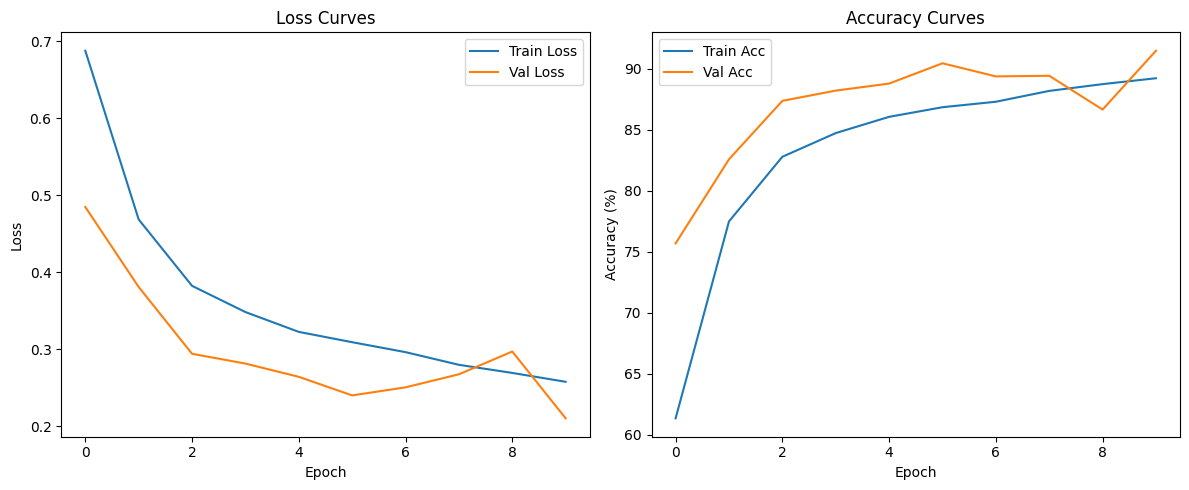

In [13]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.title('Loss Curves')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accs, label='Train Acc')
plt.plot(val_accs, label='Val Acc')
plt.title('Accuracy Curves')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.tight_layout()

plt.show()

TEST

In [14]:

best_model.eval()
correct_test = 0
total_test = 0
test_loss = 0.0
    
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
            
        outputs = best_model(images)
        logits = best_model.get_logits(outputs)
        loss = criterion(logits, labels)
            
        test_loss += loss.item() * images.size(0)
        _, predicted = logits.max(1)
        total_test += labels.size(0)
        correct_test += predicted.eq(labels).sum().item()
            
test_loss = test_loss / len(test_loader.dataset)
test_acc = 100. * correct_test / total_test

print(f"--> Test Loss: {test_loss:.4f} - Test Acc: {test_acc:.2f}%\n")

--> Test Loss: 0.2086 - Test Acc: 91.72%

